# Material Planning: Backorder Prediction with Machine Learning

## Data Preprocessing & Feature Engineering

## 1. Load processed datasets

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns during inspection
pd.set_option("display.max_columns", None)

In [2]:
# Load datasets
train_path = "../data/raw/Training_BOP.csv"
test_path = "../data/raw/Testing_BOP.csv"

df_train_raw = pd.read_csv(train_path, low_memory=False)
df_test_raw = pd.read_csv(test_path, low_memory=False)

In [3]:
# Check original dataset dimensions
print(f"Training shape: {df_train_raw.shape}")
print(f"Testing shape: {df_test_raw.shape}")

Training shape: (1687861, 23)
Testing shape: (242076, 23)


## 2. Data cleaning

In [4]:
# Create a working copy to keep the originals as backup

df_train = df_train_raw.copy()
df_test = df_test_raw.copy()

In [5]:
# Confirm that the copies preserve the original dimensions
print(f"Training copy: {df_train.shape}")
print(f"Testing copy: {df_test.shape}")

Training copy: (1687861, 23)
Testing copy: (242076, 23)


### Incomplete records

Since i found in the EDA, several variables contain exactly one missing value.

In [6]:
# Inspect training records with a missing target
df_train[df_train["went_on_backorder"].isna()]

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
1687860,(1687860 rows),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Inspect testing records with a missing target
df_test[df_test["went_on_backorder"].isna()]

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,potential_issue,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
242075,(242075 rows),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Count missing values per row and display the most incomplete records
df_train.isna().sum(axis=1).sort_values(ascending=False).head()

1687860    22
615619      1
615558      1
615573      1
615581      1
dtype: int64

In [9]:
# Count missing values per row in the testing dataset
df_test.isna().sum(axis=1).sort_values(ascending=False).head()

242075    22
88602      1
88719      1
88707      1
88690      1
dtype: int64

The final row in both datasets contains 22 missing values, including the target variable.

These rows are considered incomplete records rather than isolated missing observations. Since they cannot be used for classification or model evaluation, they will be removed.

Other records with only one missing value will be handled separately during the missing-value treatment stage.

In [10]:
# Remove incomplete records without a target value in train dataset
df_train = df_train.dropna(
    subset=["went_on_backorder"]
).copy()

In [11]:
# Remove incomplete records without a target value in test
df_test = df_test.dropna(
    subset=["went_on_backorder"]
).copy()

In [12]:
print(f"Training shape: {df_train.shape}")

Training shape: (1687860, 23)


In [13]:
print(f"Testing shape: {df_test.shape}")

Testing shape: (242075, 23)


In [14]:
# Confirm that target values are complete
print(
    "Missing training targets:",
    df_train["went_on_backorder"].isna().sum()
)


Missing training targets: 0


In [15]:
print(
    "Missing testing targets:",
    df_test["went_on_backorder"].isna().sum()
)

Missing testing targets: 0


### Standardize Text Variables

In [16]:
# Identify text columns
object_columns = df_train.select_dtypes(
    include="object"
).columns.tolist()

In [17]:
object_columns

['sku',
 'potential_issue',
 'deck_risk',
 'oe_constraint',
 'ppap_risk',
 'stop_auto_buy',
 'rev_stop',
 'went_on_backorder']

In [18]:
# Remove leading and trailing spaces from text variables
for column in object_columns:
    df_train[column] = df_train[column].str.strip()
    df_test[column] = df_test[column].str.strip()

In [19]:
# Review unique categories after text standardization
for column in object_columns:
    print(f"{column}: {df_train[column].unique()}")

sku: ['1026827' '1043384' '1043696' ... '1524346' '1439563' '1502009']
potential_issue: ['No' 'Yes']
deck_risk: ['No' 'Yes']
oe_constraint: ['No' 'Yes']
ppap_risk: ['No' 'Yes']
stop_auto_buy: ['Yes' 'No']
rev_stop: ['No' 'Yes']
went_on_backorder: ['No' 'Yes']


### Review what was found on Supplier perfomance in orevious notebook

In [20]:
# Identify supplier performance variables with -99 placeholders
performance_columns = [
    "perf_6_month_avg",
    "perf_12_month_avg"
]

In [21]:
# Flag records where 6-month supplier performance is unavailable
df_train["perf_6_month_avg_missing"] = (
    df_train["perf_6_month_avg"] == -99
).astype("int8")

In [22]:
# Preserve whether supplier performance was originally unavailable
for column in performance_columns:
    df_train[f"{column}_missing"] = (
        df_train[column] == -99
    ).astype("int8")
    
    df_test[f"{column}_missing"] = (
        df_test[column] == -99
    ).astype("int8")

In [23]:
# Review the proportion of unavailable supplier performance records
placeholder_indicators = [
    "perf_6_month_avg_missing",
    "perf_12_month_avg_missing"
]

df_train[placeholder_indicators].mean().mul(100)

perf_6_month_avg_missing     7.671134
perf_12_month_avg_missing    7.231050
dtype: float64

In [24]:
# Replace placeholder codes with genuine missing values
df_train[performance_columns] = (
    df_train[performance_columns]
    .replace(-99, np.nan)
)

In [25]:
df_test[performance_columns] = (
    df_test[performance_columns]
    .replace(-99, np.nan)
)

In [26]:
# Confirm that placeholder values were removed
for column in performance_columns:
    print(
        f"{column} - train -99 values: "
        f"{(df_train[column] == -99).sum()}"
    )

perf_6_month_avg - train -99 values: 0
perf_12_month_avg - train -99 values: 0


In [27]:
# Confirm that placeholder values were removed for the testing dataset
for column in performance_columns:
    print(
        f"{column} - test -99 values: "
        f"{(df_test[column] == -99).sum()}"
    )

perf_6_month_avg - test -99 values: 0
perf_12_month_avg - test -99 values: 0


In [28]:
# Count genuine missing values after replacing placeholders
df_train[performance_columns].isna().sum()

perf_6_month_avg     129478
perf_12_month_avg    122050
dtype: int64

### Missing Value Treatment

In [29]:
# Review missing values after data cleaning
missing_values = pd.DataFrame({
    "train_missing": df_train.isna().sum(),
    "test_missing": df_test.isna().sum()
})

missing_values[missing_values.sum(axis=1) > 0]

,train_missing,test_missing
lead_time,100893,14724
perf_6_month_avg,129478,19101
perf_12_month_avg,122050,17975


Only lead_time and supplier performance variables contain missing values.

In [30]:
# Calculate missing value percentages
missing_percentage = pd.DataFrame({
    "train_%": (
        df_train.isna().mean() * 100
    ).round(2),

    "test_%": (
        df_test.isna().mean() * 100
    ).round(2)
})

missing_percentage[
    missing_percentage.sum(axis=1) > 0
]

,train_%,test_%
lead_time,5.98,6.08
perf_6_month_avg,7.67,7.89
perf_12_month_avg,7.23,7.43


- `lead_time` contains approximately 6% missing values.
- Supplier performance variables contain around 7% missing values.
- Missing values represent a relatively small proportion of the dataset.
- Removing these records would unnecessarily reduce the training data.

In [31]:
# Review numerical summary before imputation
df_train[
    [
        "lead_time",
        "perf_6_month_avg",
        "perf_12_month_avg"
    ]
].describe()

,lead_time,perf_6_month_avg,perf_12_month_avg
count,1.586967e+06,1.558382e+06,1.565810e+06
mean,7.872267e+00,7.823812e-01,7.769763e-01
std,7.056024e+00,2.370141e-01,2.304902e-01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,7.000000e-01,6.900000e-01
50%,8.000000e+00,8.500000e-01,8.300000e-01
75%,9.000000e+00,9.700000e-01,9.600000e-01
max,5.200000e+01,1.000000e+00,1.000000e+00


### Imputation strategy

In [32]:
# Calculate median values using only the training dataset
median_values = df_train[
    [
        "lead_time",
        "perf_6_month_avg",
        "perf_12_month_avg"
    ]
].median()

median_values

lead_time            8.00
perf_6_month_avg     0.85
perf_12_month_avg    0.83
dtype: float64

In [33]:
# Replace missing values in the training dataset using the training medians
df_train[
    [
        "lead_time",
        "perf_6_month_avg",
        "perf_12_month_avg"
    ]
] = df_train[
    [
        "lead_time",
        "perf_6_month_avg",
        "perf_12_month_avg"
    ]
].fillna(median_values)

In [34]:
# Apply the same training medians to the testing dataset
df_test[
    [
        "lead_time",
        "perf_6_month_avg",
        "perf_12_month_avg"
    ]
] = df_test[
    [
        "lead_time",
        "perf_6_month_avg",
        "perf_12_month_avg"
    ]
].fillna(median_values)

In [35]:
# Confirm that all missing values have been imputed
missing_values_after = pd.DataFrame({
    "train_missing": df_train.isna().sum(),
    "test_missing": df_test.isna().sum()
})

In [36]:
missing_values_after[
    missing_values_after.sum(axis=1) > 0
]

,train_missing,test_missing


- Missing values were replaced using the median calculated from the training dataset.
- The same median values were applied to the testing dataset.
- This approach avoids data leakage while preserving the size of the dataset.
- Median imputation was selected because it is robust to skewed distributions and outliers.

## 3. Feature engineering

### Encode binary variables

In [37]:
# Define binary (Yes/No) variables
binary_columns = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "stop_auto_buy",
    "rev_stop",
    "went_on_backorder"
]

In [38]:
# Review unique values before encoding
for column in binary_columns:
    print(f"\n{column}")
    print(df_train[column].value_counts(dropna=False))


potential_issue
potential_issue
No     1686953
Yes        907
Name: count, dtype: int64

deck_risk
deck_risk
No     1300377
Yes     387483
Name: count, dtype: int64

oe_constraint
oe_constraint
No     1687615
Yes        245
Name: count, dtype: int64

ppap_risk
ppap_risk
No     1484026
Yes     203834
Name: count, dtype: int64

stop_auto_buy
stop_auto_buy
Yes    1626774
No       61086
Name: count, dtype: int64

rev_stop
rev_stop
No     1687129
Yes        731
Name: count, dtype: int64

went_on_backorder
went_on_backorder
No     1676567
Yes      11293
Name: count, dtype: int64


All binary features contain only two valid categories ("Yes" and "No"), making them suitable for binary encoding.

In [39]:
# Define binary encoding
binary_mapping = {
    "No": 0,
    "Yes": 1
}

In [40]:
# Encode binary variables in both datasets
for column in binary_columns:
    df_train[column] = df_train[column].map(binary_mapping)
    df_test[column] = df_test[column].map(binary_mapping)

In [41]:
# Verify binary encoding
for column in binary_columns:
    print(f"\n{column}")
    print(df_train[column].value_counts(dropna=False))


potential_issue
potential_issue
0    1686953
1        907
Name: count, dtype: int64

deck_risk
deck_risk
0    1300377
1     387483
Name: count, dtype: int64

oe_constraint
oe_constraint
0    1687615
1        245
Name: count, dtype: int64

ppap_risk
ppap_risk
0    1484026
1     203834
Name: count, dtype: int64

stop_auto_buy
stop_auto_buy
1    1626774
0      61086
Name: count, dtype: int64

rev_stop
rev_stop
0    1687129
1        731
Name: count, dtype: int64

went_on_backorder
went_on_backorder
0    1676567
1      11293
Name: count, dtype: int64


In [42]:
# Confirm encoded variables are numeric
df_train[binary_columns].dtypes

potential_issue      int64
deck_risk            int64
oe_constraint        int64
ppap_risk            int64
stop_auto_buy        int64
rev_stop             int64
went_on_backorder    int64
dtype: object

Binary categorical variables were encoded using a simple mapping:

- No → 0
- Yes → 1

### Review the variable "SKU"

In [43]:
# Count unique SKUs
unique_skus = df_train["sku"].nunique()

print(f"Unique SKUs: {unique_skus:,}")

Unique SKUs: 1,687,860


In [44]:
# Compare unique SKUs with total observations
print(f"Rows: {len(df_train):,}")
print(f"Unique SKUs: {df_train['sku'].nunique():,}")

Rows: 1,687,860
Unique SKUs: 1,687,860


In [45]:
# Review the most frequent SKUs
sku_frequency = df_train["sku"].value_counts()

sku_frequency.head(10)

sku
1026827    1
1489888    1
1489898    1
1489897    1
1489896    1
1489895    1
1489894    1
1489893    1
1489892    1
1489891    1
Name: count, dtype: int64

In [46]:
# Review SKU frequency distribution
sku_frequency.describe()

count    1687860.0
mean           1.0
std            0.0
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            1.0
Name: count, dtype: float64

- Every observation corresponds to a unique SKU.
- Each SKU appears exactly once in the training dataset.
- No SKUs are shared between the training and testing datasets.
- SKU acts only as a product identifier and provides no reusable predictive information.
- The variable was removed to improve model generalization and avoid using a high-cardinality identifier.

In [47]:
# Remove SKU identifier
df_train = df_train.drop(columns="sku")
df_test = df_test.drop(columns="sku")

### Feature ideation

New variables will be engineered only when they represent meaningful supply chain concepts that could improve the predictive performance of the model.

The following candidate features will be explored:

- Operational Risk Score (Combines potential_issue, deck_risk, oe_constraint, ppap_risk and rev_stop into a single operational risk indicator.)
- Inventory Coverage (Measures how many forecast periods the current inventory can cover using national_inv / forecast_3_month.)
- Inventory Gap (Measures the difference between current inventory and forecast demand using national_inv - forecast_3_month.)

In [48]:
# Variables representing operational supply chain risks
risk_columns = [
    "potential_issue",
    "deck_risk",
    "oe_constraint",
    "ppap_risk",
    "rev_stop"
]

In [49]:
# Create an operational risk score for both datasets
df_train["operational_risk_score"] = df_train[risk_columns].sum(axis=1)

df_test["operational_risk_score"] = df_test[risk_columns].sum(axis=1)

In [50]:
# Review the new feature distribution
df_train["operational_risk_score"].value_counts().sort_index()

operational_risk_score
0    1150848
1     480971
2      55894
3        147
Name: count, dtype: int64

In [51]:
# Review operational risk score percentages
(
    df_train["operational_risk_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

operational_risk_score
0    68.18
1    28.50
2     3.31
3     0.01
Name: proportion, dtype: float64

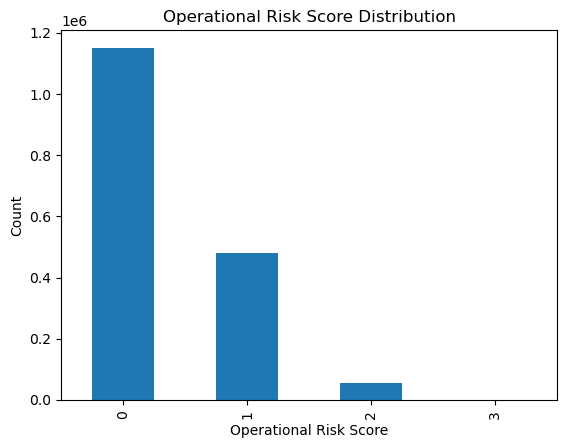

In [52]:
# Visualize operational risk score distribution
df_train["operational_risk_score"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Operational Risk Score Distribution")
plt.xlabel("Operational Risk Score")
plt.ylabel("Count")

plt.show()

- Around 68% of products have no operational risk flags.
- Approximately 29% of products present a single operational risk.
- Products with multiple simultaneous risks are relatively uncommon.
- I will evaluate its predictive value will be evaluated during feature selection and model training.

### Inventory coverage

In [53]:
# Count products with zero 3-month forecast
(df_train["forecast_3_month"] == 0).sum()

np.int64(1177722)

In [54]:
forecast_zero_percentage = (
    (df_train["forecast_3_month"] == 0)
    .mean()
    * 100
)

print(f"Zero forecast percentage: {forecast_zero_percentage:.2f}%")

Zero forecast percentage: 69.78%


In [55]:
# Create inventory coverage feature for train dataset
df_train["inventory_coverage"] = np.where( #Avoid dividing by 0 (where)
    df_train["forecast_3_month"] > 0,
    df_train["national_inv"] / df_train["forecast_3_month"],
    np.nan
)

In [56]:
# Create inventory coverage feature for test
df_test["inventory_coverage"] = np.where(  #Avoid dividing by 0 (where)
    df_test["forecast_3_month"] > 0,
    df_test["national_inv"] / df_test["forecast_3_month"],
    np.nan
)

In [57]:
df_train["inventory_coverage"].describe()

count    510138.000000
mean          1.835638
std          23.701805
min         -40.100000
25%           0.327586
50%           0.824048
75%           1.642857
max        7152.333333
Name: inventory_coverage, dtype: float64

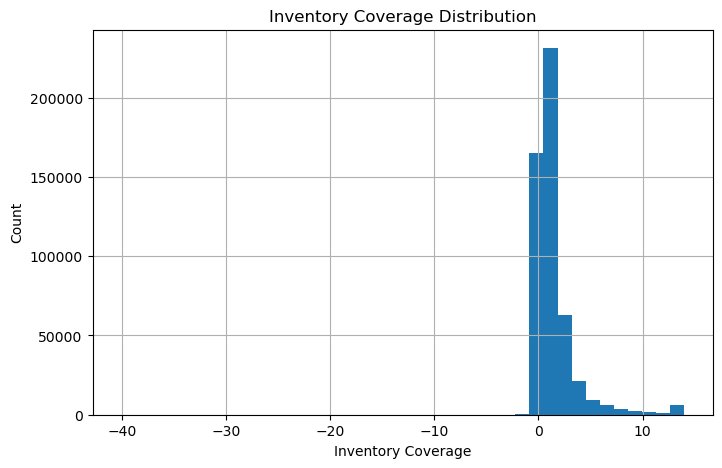

In [58]:
plt.figure(figsize=(8,5))

df_train["inventory_coverage"].clip(
    upper=df_train["inventory_coverage"].quantile(0.99)
).hist(bins=40)

plt.title("Inventory Coverage Distribution")
plt.xlabel("Inventory Coverage")
plt.ylabel("Count")

plt.show()

- Nearly 70% of products have a zero 3-month forecast, so inventory coverage cannot be computed for those records.
- Inventory coverage was calculated only when forecast demand was greater than zero.
- The distribution is strongly right-skewed, with a few products showing extremely high inventory coverage.
- Negative inventory coverage values are present due to negative inventory levels observed during the EDA.
- Most products with valid values show relatively low inventory coverage, indicating limited stock relative to forecast demand.

In [59]:
# Flag products whose inventory coverage cannot be calculated
# 1 = forecast_3_month is zero
# 0 = forecast_3_month is greater than zero

df_train["zero_3m_forecast"] = (
    df_train["forecast_3_month"] == 0
).astype("int8")

In [60]:
df_test["zero_3m_forecast"] = (
    df_test["forecast_3_month"] == 0
).astype("int8")

In [61]:
# Review the new indicator distribution
df_train["zero_3m_forecast"].value_counts()

zero_3m_forecast
1    1177722
0     510138
Name: count, dtype: int64

In [62]:
# Review indicator percentages
(
    df_train["zero_3m_forecast"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

zero_3m_forecast
0    30.22
1    69.78
Name: proportion, dtype: float64

In [63]:
# Replace undefined inventory coverage values with 0
# zero_3m_forecast preserves the reason why coverage was unavailable

df_train["inventory_coverage"] = (
    df_train["inventory_coverage"]
    .fillna(0)
)

In [64]:
df_test["inventory_coverage"] = (
    df_test["inventory_coverage"]
    .fillna(0)
)

In [65]:
# Confirm that inventory coverage no longer contains missing values
print(
    "Train inventory coverage missing:",
    df_train["inventory_coverage"].isna().sum()
)

Train inventory coverage missing: 0


In [66]:
print(
    "Test inventory coverage missing:",
    df_test["inventory_coverage"].isna().sum()
)

Test inventory coverage missing: 0


In [67]:
# Inspect products with a valid inventory coverage calculation
df_train.loc[
    df_train["zero_3m_forecast"] == 0,
    [
        "national_inv",
        "forecast_3_month",
        "inventory_coverage",
        "zero_3m_forecast"
    ]
].head()

,national_inv,forecast_3_month,inventory_coverage,zero_3m_forecast
8,140.0,15.0,9.333333,0
36,0.0,174.0,0.000000,0
77,0.0,2.0,0.000000,0
97,59.0,181.0,0.325967,0
115,6.0,22.0,0.272727,0


Inventory Coverage could not be calculated when the 3-month forecast was zero:

- Instead of imputing these records with a statistical value, a new binary indicator (`zero_3m_forecast`) was created to preserve this business condition.
- Undefined coverage values were then replaced with zero as a technical modeling value. The indicator allows the model to distinguish between genuine zero coverage and coverage that could not be calculated because no forecast was available.

### Inventory gap

In [68]:
# Create inventory gap feature
df_train["inventory_gap"] = (
    df_train["national_inv"]
    - df_train["forecast_3_month"]
)

In [69]:
df_test["inventory_gap"] = (
    df_test["national_inv"]
    - df_test["forecast_3_month"]
)

In [70]:
df_train["inventory_gap"].describe()

count    1.687860e+06
mean     3.179925e+02
std      2.964872e+04
min     -8.057110e+05
25%      2.000000e+00
50%      9.000000e+00
75%      4.300000e+01
max      1.233440e+07
Name: inventory_gap, dtype: float64

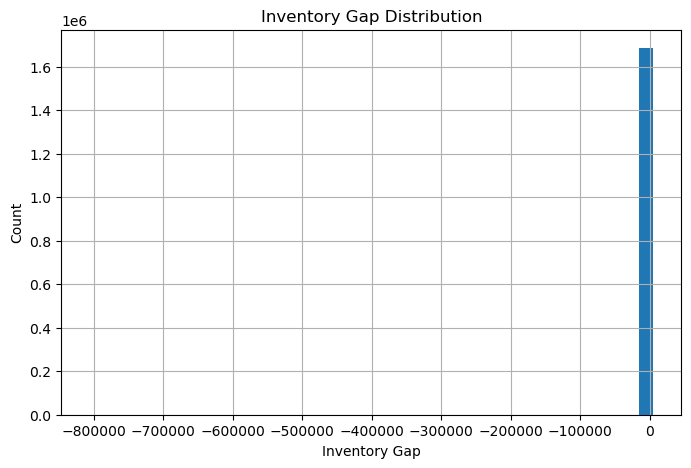

In [71]:
plt.figure(figsize=(8,5))

df_train["inventory_gap"].clip(
    upper=df_train["inventory_gap"].quantile(0.99)
).hist(bins=40)

plt.title("Inventory Gap Distribution")
plt.xlabel("Inventory Gap")
plt.ylabel("Count")

plt.show()

- The median inventory is around 9 units, indicating that most products have slightly more inventory than forecast demand.
- The distribution contains large positive and negative outliers.
- Most products are concentrated near zero, while only a small number show very large inventory surpluses or deficits.
- Inventory Gap complements Inventory Coverage by measuring the absolute inventory surplus or shortage instead of a relative ratio.

### Feature evaluation

In [72]:
# Engineered features to evaluate

engineered_features = [
    "operational_risk_score",
    "inventory_coverage",
    "inventory_gap"
]

In [73]:
# Compare feature averages by target class

df_train.groupby("went_on_backorder")[
    engineered_features
].mean()

,operational_risk_score,inventory_coverage,inventory_gap
went_on_backorder,,,
0,0.351591,0.557038,321.049698
1,0.330647,0.222854,-135.881608


In [74]:
# Count unique values in every feature

unique_values = pd.DataFrame({
    "unique_values": df_train.nunique()
})

unique_values.sort_values("unique_values").head(10)

,unique_values
potential_issue,2
went_on_backorder,2
rev_stop,2
stop_auto_buy,2
ppap_risk,2
oe_constraint,2
deck_risk,2
zero_3m_forecast,2
perf_6_month_avg_missing,2
perf_12_month_avg_missing,2


In [75]:
# Select numerical features

numeric_columns = df_train.select_dtypes(include=np.number).columns

In [76]:
# Correlation matrix

correlation_matrix = df_train[numeric_columns].corr()

In [77]:
# Find highly correlated feature pairs

corr_pairs = (
    correlation_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[
    (corr_pairs < 1)
    & (corr_pairs > 0.95)
]

corr_pairs

forecast_6_month           forecast_9_month             0.994945
forecast_9_month           forecast_6_month             0.994945
forecast_3_month           forecast_6_month             0.990490
forecast_6_month           forecast_3_month             0.990490
inventory_gap              national_inv                 0.985613
national_inv               inventory_gap                0.985613
forecast_3_month           forecast_9_month             0.977337
forecast_9_month           forecast_3_month             0.977337
sales_3_month              sales_6_month                0.975594
sales_6_month              sales_3_month                0.975594
                           sales_9_month                0.971833
sales_9_month              sales_6_month                0.971833
perf_6_month_avg_missing   perf_12_month_avg_missing    0.968586
perf_12_month_avg_missing  perf_6_month_avg_missing     0.968586
dtype: float64

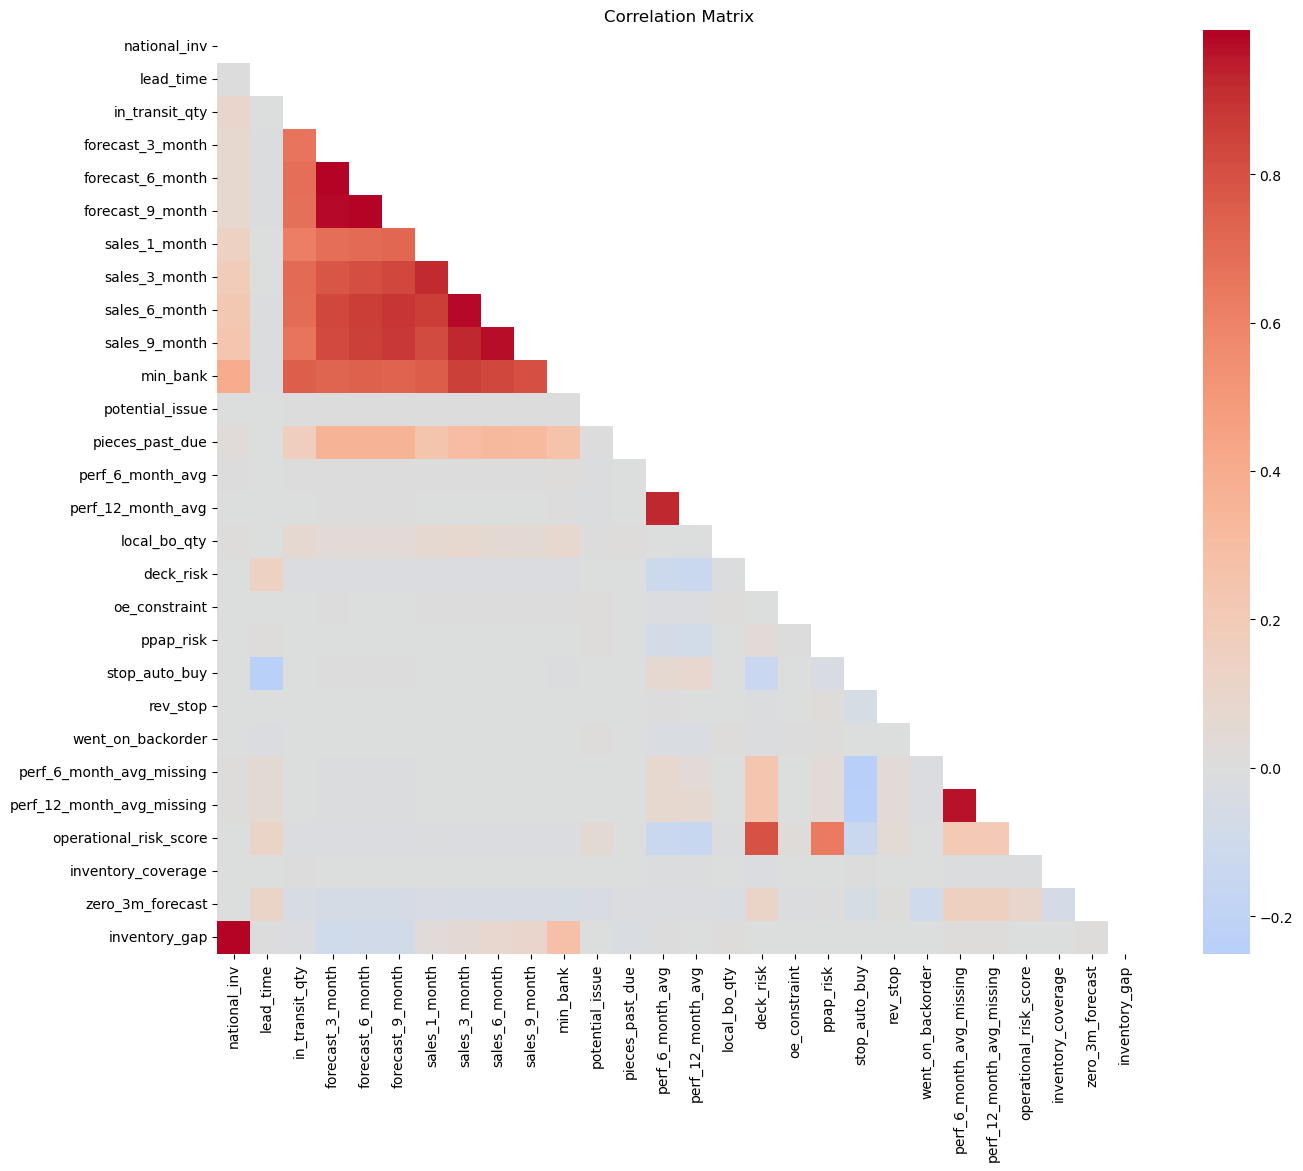

In [78]:
# Correlation heatmap for numerical features
plt.figure(figsize=(16,12))

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

Although some correlations exceed 0.95, these variables represent different operational concepts. Therefore, they were retained at this stage and their predictive contribution will be evaluated during the modeling phase using feature importance techniques.

### Final dataset validation

In [79]:
# Review final dataset dimensions

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (1687860, 28)
Test shape: (242075, 28)


In [80]:
# Review remaining missing values

missing_summary = pd.DataFrame({
    "train_missing": df_train.isna().sum(),
    "test_missing": df_test.isna().sum()
})

missing_summary[
    missing_summary.sum(axis=1) > 0
]

,train_missing,test_missing


In [81]:
# Confirm no duplicated rows remain

print("Train duplicates:", df_train.duplicated().sum())
print("Test duplicates:", df_test.duplicated().sum())

Train duplicates: 667788
Test duplicates: 56709


In [82]:
# Review final data types

df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1687860 entries, 0 to 1687859
Data columns (total 28 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   national_inv               1687860 non-null  float64
 1   lead_time                  1687860 non-null  float64
 2   in_transit_qty             1687860 non-null  float64
 3   forecast_3_month           1687860 non-null  float64
 4   forecast_6_month           1687860 non-null  float64
 5   forecast_9_month           1687860 non-null  float64
 6   sales_1_month              1687860 non-null  float64
 7   sales_3_month              1687860 non-null  float64
 8   sales_6_month              1687860 non-null  float64
 9   sales_9_month              1687860 non-null  float64
 10  min_bank                   1687860 non-null  float64
 11  potential_issue            1687860 non-null  int64  
 12  pieces_past_due            1687860 non-null  float64
 13  perf_6_month_avg 

In [83]:
# Double check if the duplictaes are because we don't have skus

# Define predictor columns, excluding the target
feature_columns = [
    column
    for column in df_train.columns
    if column != "went_on_backorder"
]

In [84]:
# Count rows with duplicated predictor combinations
duplicated_feature_rows = df_train.duplicated(
    subset=feature_columns,
    keep=False
)

In [85]:
print(
    "Rows sharing the same predictor values:",
    duplicated_feature_rows.sum()
)

Rows sharing the same predictor values: 836653


In [86]:
# Check whether identical predictor combinations have different target values
target_variation = (
    df_train.loc[duplicated_feature_rows]
    .groupby(
        feature_columns,
        dropna=False
    )["went_on_backorder"]
    .nunique()
)

In [87]:
conflicting_patterns = (
    target_variation > 1
).sum()

In [88]:
print(
    "Predictor combinations with different target values:",
    conflicting_patterns
)

Predictor combinations with different target values: 390


After removing the SKU identifier, many products share identical predictor values.

This is expected because different products can exhibit the same inventory, forecast, sales and supplier characteristics.

A further inspection shows that only a small number of predictor combinations (390) are associated with different target labels.

This indicates that the available variables do not completely explain every backorder event, suggesting that additional external factors influence the target.

Therefore, duplicated predictor combinations were retained, since each observation represents a different product and contributes useful information to the learning process.

### Export datasets with new variables and the original for start

In [89]:
# Features created during cleaning and feature engineering
engineered_features = [
    "perf_6_month_avg_missing",
    "perf_12_month_avg_missing",
    "operational_risk_score",
    "inventory_coverage",
    "zero_3m_forecast",
    "inventory_gap"
]

In [90]:
# Create baseline datasets using only cleaned original variables
df_train_baseline = df_train.drop(
    columns=engineered_features
).copy()

In [91]:
df_test_baseline = df_test.drop(
    columns=engineered_features
).copy()

In [92]:
# Create datasets containing all engineered features
df_train_engineered = df_train.copy()
df_test_engineered = df_test.copy()

In [93]:
# Confirm that no missing values remain
print(
    "Baseline train missing:",
    df_train_baseline.isna().sum().sum()
)

Baseline train missing: 0


In [94]:
print(
    "Baseline test missing:",
    df_test_baseline.isna().sum().sum()
)

Baseline test missing: 0


In [95]:
print(
    "Engineered train missing:",
    df_train_engineered.isna().sum().sum()
)

Engineered train missing: 0


In [96]:
print(
    "Engineered test missing:",
    df_test_engineered.isna().sum().sum()
)

Engineered test missing: 0


In [97]:
# Confirm that train and test contain the same columns
print(
    "Baseline columns match:",
    df_train_baseline.columns.tolist()
    == df_test_baseline.columns.tolist()
)

Baseline columns match: True


In [98]:
print(
    "Engineered columns match:",
    df_train_engineered.columns.tolist()
    == df_test_engineered.columns.tolist()
)

Engineered columns match: True


In [99]:
# Export baseline datasets
df_train_baseline.to_csv(
    "../data/processed/train_baseline.csv",
    index=False
)

In [100]:
df_test_baseline.to_csv(
    "../data/processed/test_baseline.csv",
    index=False
)

In [101]:
# Export datasets with engineered features
df_train_engineered.to_csv(
    "../data/processed/train_engineered.csv",
    index=False
)


In [102]:
df_test_engineered.to_csv(
    "../data/processed/test_engineered.csv",
    index=False
)